# Position Bias Results — Brief

This notebook presents the current cached benchmark results concisely.

Focus:
- coverage gaps
- randomized vs fixed-position bias
- fixed-letter differences across models
- simple chi-squared checks for randomized answer skew

Interpretation rule:
- GPT is the only complete matrix
- Qwen is included as a partial comparison and should be treated as semi-complete


In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from inspect_ai.log import list_eval_logs, read_eval_log, read_eval_log_sample_summaries

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'w1').exists():
            return candidate
    if cwd.name == 'w1' and (cwd.parent / 'pyproject.toml').exists():
        return cwd.parent
    return cwd

PROJECT_ROOT = resolve_project_root()
LOG_DIR = PROJECT_ROOT / 'w1' / 'position_bias_exploration_logs'
OUTPUT_DIR = PROJECT_ROOT / 'w1' / 'position_bias_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED = {
    4: ['randomized', 'fixed_A', 'fixed_B', 'fixed_C', 'fixed_D'],
    6: ['randomized', 'fixed_A', 'fixed_B', 'fixed_C', 'fixed_D', 'fixed_E', 'fixed_F'],
}

def answer_letters(option_count: int) -> list[str]:
    return list('ABCDEFGHIJKLMNOPQRSTUVWXYZ'[:option_count])

def fixed_position_label(position: int | None, option_count: int) -> str:
    if position is None:
        return 'randomized'
    return f'fixed_{answer_letters(option_count)[position]}'

def extract_predicted_letter(score, option_count: int) -> str | None:
    labels = set(answer_letters(option_count))
    answer = getattr(score, 'answer', None)
    if isinstance(answer, str):
        cleaned = answer.strip().replace('$', '')
        if cleaned in labels:
            return cleaned
    explanation = getattr(score, 'explanation', '') or ''
    match = re.search(r'ANSWER:\s*\$?([A-Z])', explanation)
    if match and match.group(1) in labels:
        return match.group(1)
    return None

def cached_index(log_dir: Path, n_questions: int = 28):
    latest_by_model = {}
    redundant = []
    for info in list_eval_logs(log_dir=str(log_dir)):
        log = read_eval_log(info, header_only=True)
        metadata = log.eval.metadata or {}
        if log.status != 'success':
            continue
        if metadata.get('benchmark') != 'position_bias_exploration':
            continue
        if int(metadata.get('n_questions', -1)) != n_questions:
            continue
        key = (int(metadata['option_count']), metadata['condition_label'])
        model_label = metadata['model_label']
        latest = latest_by_model.setdefault(model_label, {})
        if key in latest:
            redundant.append(info.name)
            continue
        latest[key] = info
    return latest_by_model, redundant

def build_sample_frame(log_index_by_model):
    rows = []
    for model_label, log_index in sorted(log_index_by_model.items()):
        for (option_count, condition_label), info in sorted(log_index.items()):
            log = read_eval_log(info, header_only=True)
            metadata = log.eval.metadata or {}
            for sample in read_eval_log_sample_summaries(info):
                score = next(iter(sample.scores.values()))
                rows.append({
                    'model_label': model_label,
                    'option_count': option_count,
                    'condition_label': condition_label,
                    'correct_position': metadata['correct_position'],
                    'fixed_position_label': fixed_position_label(metadata['correct_position'], option_count),
                    'predicted': extract_predicted_letter(score, option_count),
                    'correct': score.value == 'C',
                    'working_time': sample.working_time,
                })
    return pd.DataFrame(rows)

def monte_carlo_uniform_pvalue(counts: list[int], simulations: int = 5000, seed: int = 42):
    observed = np.array(counts, dtype=float)
    n = int(observed.sum())
    k = len(observed)
    if n == 0 or k <= 1:
        return float('nan'), float('nan')
    expected = n / k
    chi2 = float(((observed - expected) ** 2 / expected).sum())
    rng = np.random.default_rng(seed)
    sims = rng.multinomial(n, [1 / k] * k, size=simulations)
    sim_stats = ((sims - expected) ** 2 / expected).sum(axis=1)
    p_value = float((np.count_nonzero(sim_stats >= chi2) + 1) / (simulations + 1))
    return chi2, p_value

sns.set_theme(style='whitegrid')
log_index, redundant_logs = cached_index(LOG_DIR)
sample_df = build_sample_frame(log_index)
print(f'Project root: {PROJECT_ROOT}')
print('Loaded models:', ', '.join(sorted(log_index)))
print(f'Redundant successful logs: {len(redundant_logs)}')

Project root: /Users/zakhar/Desktop/code/monoid
Loaded models: gpt-5-codex-mini, qwen3.5-122b-a10b
Redundant successful logs: 31


In [2]:
coverage_rows = []
for model_label, model_index in sorted(log_index.items()):
    missing = [
        f'{option_count}:{condition_label}'
        for option_count, conditions in EXPECTED.items()
        for condition_label in conditions
        if (option_count, condition_label) not in model_index
    ]
    coverage_rows.append({
        'model': model_label,
        'available': len(model_index),
        'expected': sum(len(v) for v in EXPECTED.values()),
        'complete': not missing,
        'missing': ', '.join(missing),
    })
coverage_df = pd.DataFrame(coverage_rows)
display(Markdown('## Coverage gaps'))
display(coverage_df)

run_summary = (
    sample_df.groupby(['model_label', 'option_count', 'condition_label', 'fixed_position_label'], dropna=False)
    .agg(n=('correct', 'size'), correct_n=('correct', 'sum'), avg_working_time=('working_time', 'mean'))
    .reset_index()
    .assign(accuracy=lambda df: df['correct_n'] / df['n'])
    .sort_values(['model_label', 'option_count', 'condition_label'])
)

rand_rows = []
randomized = sample_df[sample_df['condition_label'] == 'randomized'].copy()
for (model_label, option_count), group in randomized.groupby(['model_label', 'option_count']):
    labels = answer_letters(int(option_count))
    counts = [int((group['predicted'] == label).sum()) for label in labels]
    chi2, p_value = monte_carlo_uniform_pvalue(counts)
    rand_rows.append({
        'model': model_label,
        'options': option_count,
        'randomized_accuracy': round(float(group['correct'].mean()), 3),
        'chi2': round(chi2, 3),
        'p_value': round(p_value, 4),
        'significant_p_lt_0.05': bool(p_value < 0.05) if p_value == p_value else False,
        'counts': str(dict(zip(labels, counts))),
    })
randomized_stats = pd.DataFrame(rand_rows).sort_values(['model', 'options'])

gap_rows = []
fixed = run_summary[run_summary['condition_label'] != 'randomized'].copy()
for (model_label, option_count), group in fixed.groupby(['model_label', 'option_count']):
    gap_rows.append({
        'model': model_label,
        'options': option_count,
        'fixed_conditions_present': len(group),
        'min_accuracy': round(group['accuracy'].min(), 3),
        'max_accuracy': round(group['accuracy'].max(), 3),
        'gap': round(group['accuracy'].max() - group['accuracy'].min(), 3),
    })
fixed_gap_df = pd.DataFrame(gap_rows).sort_values(['model', 'options'])

display(Markdown('## Randomized vs fixed'))
display(randomized_stats)
display(fixed_gap_df)

display(Markdown('## Concise takeaways'))
display(Markdown(
    '- GPT is the only complete matrix; Qwen is still missing 6-choice fixed_C and fixed_D.\n'
    '- Randomized-answer skew is not statistically significant in the cached runs shown here (chi-squared Monte Carlo p-values stay above 0.05).\n'
    '- The stronger effect is fixed-position sensitivity: fixed-slot accuracy ranges are materially wider than randomized accuracy alone suggests.\n'
    '- Models differ somewhat in which fixed letters look stronger, but Qwen comparisons are still partial.'
))


## Coverage gaps

,model,available,expected,complete,missing
0,gpt-5-codex-mini,12,12,True,
1,qwen3.5-122b-a10b,10,12,False,"6:fixed_C, 6:fixed_D"


## Randomized vs fixed

,model,options,randomized_accuracy,chi2,p_value,significant_p_lt_0.05,counts
0,gpt-5-codex-mini,4,0.857,0.000,1.0000,False,"{'A': 7, 'B': 7, 'C': 7, 'D': 7}"
1,gpt-5-codex-mini,6,0.750,2.000,0.8878,False,"{'A': 3, 'B': 3, 'C': 6, 'D': 5, 'E': 6, 'F': 5}"
2,qwen3.5-122b-a10b,4,0.786,0.571,0.9238,False,"{'A': 8, 'B': 6, 'C': 6, 'D': 8}"
3,qwen3.5-122b-a10b,6,0.607,8.429,0.1286,False,"{'A': 3, 'B': 2, 'C': 8, 'D': 8, 'E': 2, 'F': 5}"


,model,options,fixed_conditions_present,min_accuracy,max_accuracy,gap
0,gpt-5-codex-mini,4,4,0.679,1.000,0.321
1,gpt-5-codex-mini,6,6,0.714,1.000,0.286
2,qwen3.5-122b-a10b,4,4,0.571,0.821,0.250
3,qwen3.5-122b-a10b,6,4,0.571,0.786,0.214


## Concise takeaways

- GPT is the only complete matrix; Qwen is still missing 6-choice fixed_C and fixed_D.
- Randomized-answer skew is not statistically significant in the cached runs shown here (chi-squared Monte Carlo p-values stay above 0.05).
- The stronger effect is fixed-position sensitivity: fixed-slot accuracy ranges are materially wider than randomized accuracy alone suggests.
- Models differ somewhat in which fixed letters look stronger, but Qwen comparisons are still partial.

## Accuracy by condition

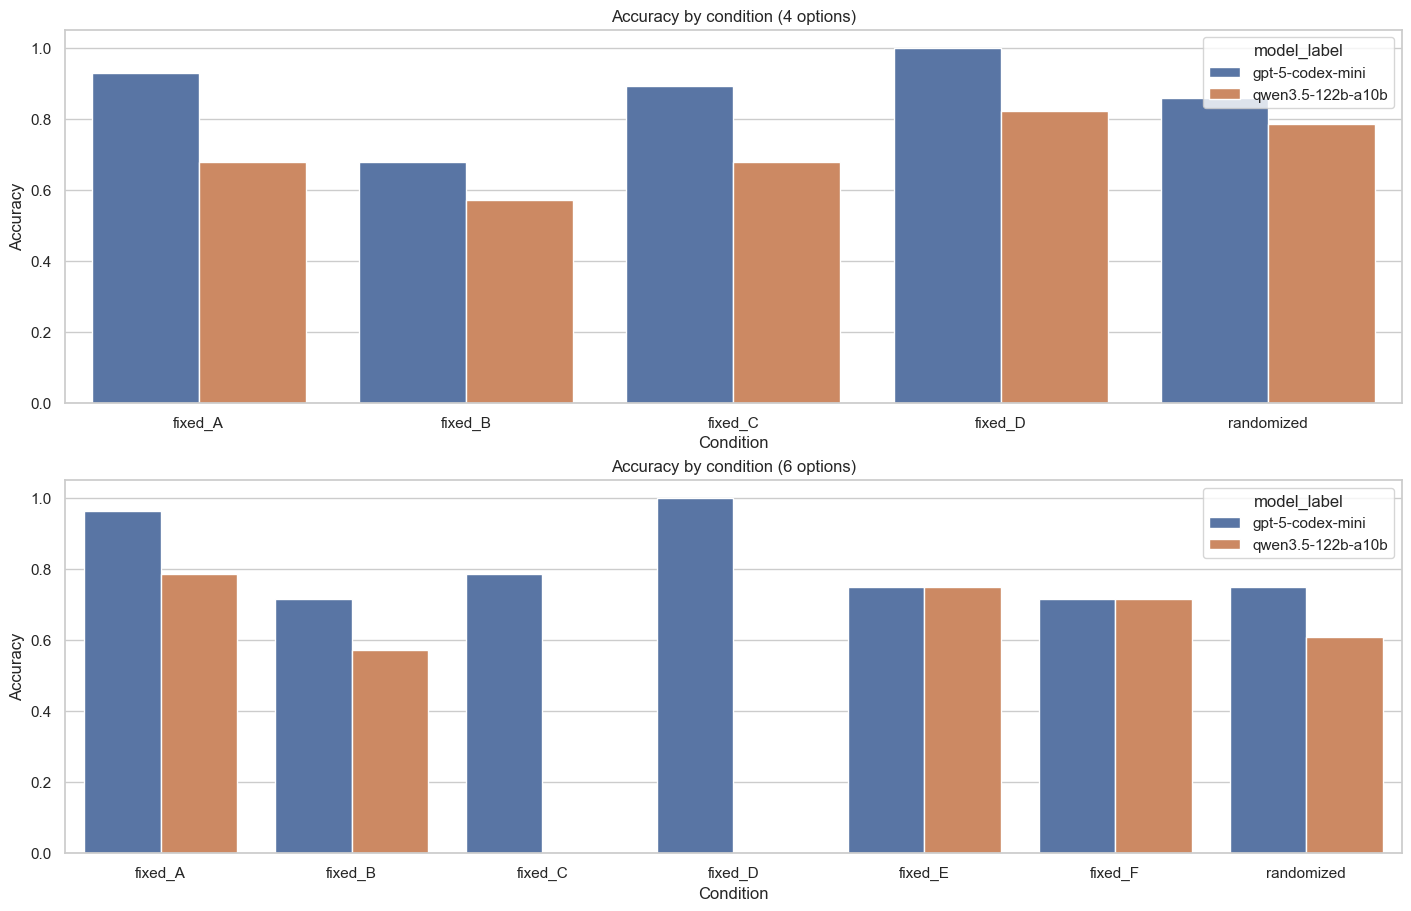

In [3]:
display(Markdown('## Accuracy by condition'))
plot_df = run_summary.copy()
plot_df['condition_plot'] = plot_df['fixed_position_label']
fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
for ax, option_count in zip(axes, [4, 6]):
    subset = plot_df[plot_df['option_count'] == option_count]
    sns.barplot(data=subset, x='condition_plot', y='accuracy', hue='model_label', ax=ax)
    ax.set_title(f'Accuracy by condition ({option_count} options)')
    ax.set_xlabel('Condition')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
display(fig)
plt.close(fig)


## Fixed-letter differences

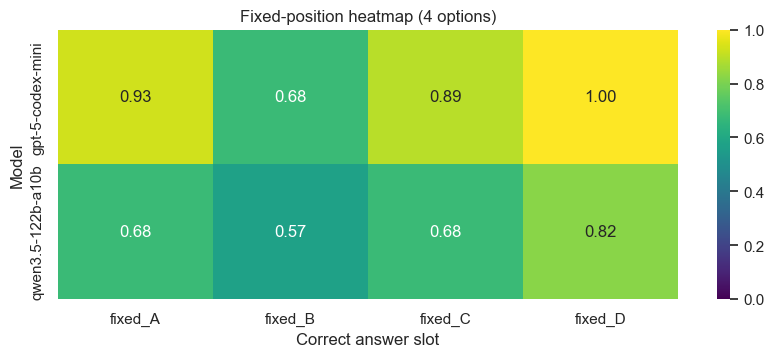

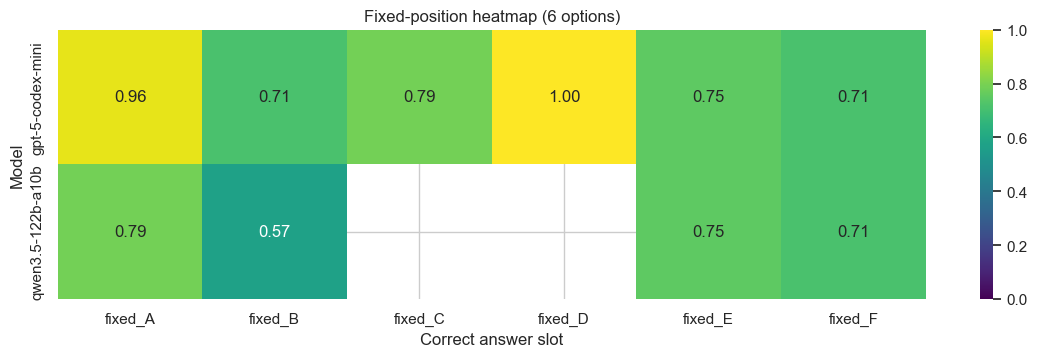

In [4]:
display(Markdown('## Fixed-letter differences'))
fixed_df = run_summary[run_summary['condition_label'] != 'randomized'].copy()
for option_count in [4, 6]:
    subset = fixed_df[fixed_df['option_count'] == option_count]
    if subset.empty:
        continue
    pivot = subset.pivot(index='model_label', columns='fixed_position_label', values='accuracy')
    ordered = [fixed_position_label(i, option_count) for i in range(option_count)]
    pivot = pivot.reindex(columns=ordered)
    fig, ax = plt.subplots(figsize=(2 + 2 * option_count, 3.5))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, ax=ax)
    ax.set_title(f'Fixed-position heatmap ({option_count} options)')
    ax.set_xlabel('Correct answer slot')
    ax.set_ylabel('Model')
    display(fig)
    plt.close(fig)
